In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [31]:
df = pd.read_csv("../data/customer_churn_cleaned.csv")

In [32]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [33]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

binary_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

categorical_features = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [34]:
binary_map = {
    "Yes":1,
    "No":0,
    "Male":1,
    "Female":0
}

for col in binary_features:
    X[col] = X[col].replace(binary_map)

C:\Users\G-USER\AppData\Local\Temp\ipykernel_2352\1956343220.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].replace(binary_map)


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [38]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808131,0.671141,0.539084,0.597907,0.722015
2,Random Forest,0.786020,0.628159,0.469003,0.537037,0.684550
1,Decision Tree,0.717546,0.465753,0.458221,0.461957,0.634542


In [39]:
best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808131,0.671141,0.539084,0.597907,0.722015
2,Random Forest,0.786020,0.628159,0.469003,0.537037,0.684550
1,Decision Tree,0.717546,0.465753,0.458221,0.461957,0.634542


In [40]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

In [41]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808131,0.671141,0.539084,0.597907,0.722015
1,Decision Tree,0.717546,0.465753,0.458221,0.461957,0.634542
2,Random Forest,0.786020,0.628159,0.469003,0.537037,0.684550


# Key Findings

1. Three classification models were evaluated for customer churn prediction.

2. Logistic Regression achieved the highest overall performance with:
   - Accuracy: 80.81%
   - Precision: 67.11%
   - Recall: 53.91%
   - F1 Score: 59.79%
   - ROC-AUC: 72.20%

3. Random Forest produced competitive results but did not outperform Logistic Regression using the default parameters.

4. Decision Tree showed the lowest predictive performance, indicating that it was more prone to overfitting.

5. Based on the evaluation metrics, Logistic Regression was selected as the best-performing baseline model for customer churn prediction.

# Conclusion

The comparison of multiple machine learning models demonstrated that Logistic Regression achieved the best balance between predictive accuracy and classification performance. Although ensemble methods such as Random Forest are often powerful, the current dataset was best modeled using Logistic Regression. Future improvements may include hyperparameter tuning, additional feature engineering, and class imbalance techniques to further improve churn detection.

In [42]:
# Support Vector Machine

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_prob = svm_model.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

svm_results = {

    "Model":"Support Vector Machine",

    "Accuracy":accuracy_score(y_test, svm_pred),

    "Precision":precision_score(y_test, svm_pred),

    "Recall":recall_score(y_test, svm_pred),

    "F1 Score":f1_score(y_test, svm_pred),

    "ROC AUC":roc_auc_score(y_test, svm_prob)

}

svm_results

{'Model': 'Support Vector Machine',
 'Accuracy': 0.8002853067047075,
 'Precision': 0.6691449814126395,
 'Recall': 0.48517520215633425,
 'F1 Score': 0.5625,
 'ROC AUC': 0.7774777059406381}

In [44]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         random_state=42,
         eval_metric="logloss"
     ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [45]:
xgb_results = {

    "Model":"XGBoost",

    "Accuracy":accuracy_score(y_test, xgb_pred),

    "Precision":precision_score(y_test, xgb_pred),

    "Recall":recall_score(y_test, xgb_pred),

    "F1 Score":f1_score(y_test, xgb_pred),

    "ROC AUC":roc_auc_score(y_test, xgb_prob)

}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7774607703281027,
 'Precision': 0.594855305466238,
 'Recall': 0.49865229110512127,
 'F1 Score': 0.5425219941348973,
 'ROC AUC': 0.8216723616408845}

In [46]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                      ABCMeta                   <class 'sklearn.svm._classes.SVC'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                       gender

In [47]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8081312410841655,
  'Precision': 0.6711409395973155,
  'Recall': 0.5390835579514824,
  'F1 Score': 0.5979073243647235,
  'ROC AUC': 0.7220151058428605},
 {'Model': 'Decision Tree',
  'Accuracy': 0.717546362339515,
  'Precision': 0.4657534246575342,
  'Recall': 0.4582210242587601,
  'F1 Score': 0.46195652173913043,
  'ROC AUC': 0.634542131915995},
 {'Model': 'Random Forest',
  'Accuracy': 0.7860199714693296,
  'Precision': 0.628158844765343,
  'Recall': 0.46900269541778977,
  'F1 Score': 0.5370370370370371,
  'ROC AUC': 0.6845498443141325}]

In [48]:
len(results)

3

In [49]:
results.append(svm_results)
results.append(xgb_results)

In [50]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808131,0.671141,0.539084,0.597907,0.722015
1,Support Vector Machine,0.800285,0.669145,0.485175,0.562500,0.777478
2,Random Forest,0.786020,0.628159,0.469003,0.537037,0.684550
3,XGBoost,0.777461,0.594855,0.498652,0.542522,0.821672
4,Decision Tree,0.717546,0.465753,0.458221,0.461957,0.634542


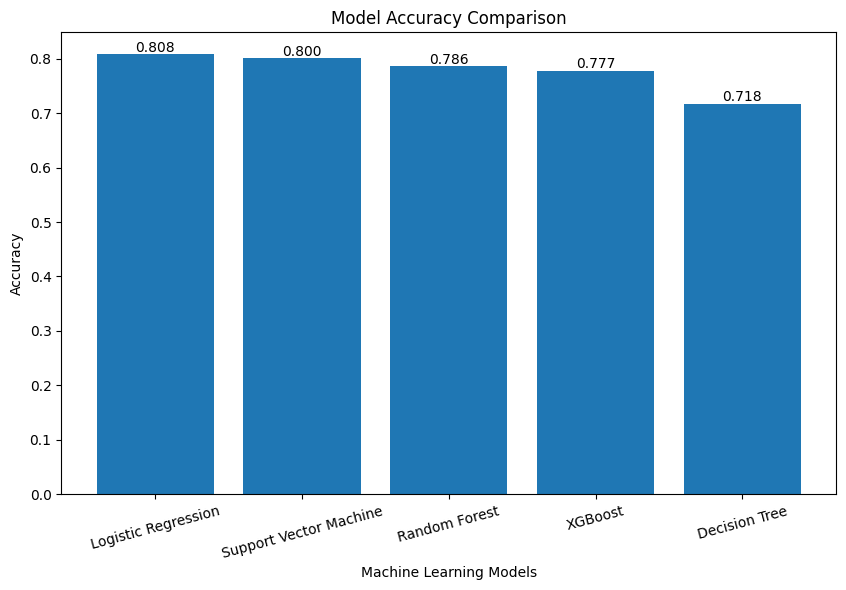

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.005, f"{value:.3f}", ha="center")

plt.show()

In [52]:
len(results)

5

In [53]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.808131,0.671141,0.539084,0.597907,0.722015
1,Support Vector Machine,0.800285,0.669145,0.485175,0.562500,0.777478
2,Random Forest,0.786020,0.628159,0.469003,0.537037,0.684550
3,XGBoost,0.777461,0.594855,0.498652,0.542522,0.821672
4,Decision Tree,0.717546,0.465753,0.458221,0.461957,0.634542
